### Initial Database and Checks


In [ ]:
import os
import tensorflow as tf

# NOTE: may have to change batch size and epochs depending on GPU VRAM. but epochs should be kept to 100 if possible for train accuracy.
CLEAR_BEFORE_TRAIN = True
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3
TRAIN_END = 15000
TEST_SIZE = int(TRAIN_END * 0.20)
HOLDOUT_END = TRAIN_END + 2000
STEPS = TRAIN_END//2 // BATCH_SIZE + 1
BETA = 1.0

# Define your checkpoint directory
checkpoint_dir = './checkpoints/'
models_dir = './models/'
data_dir = './data/'
prep_model_path = os.path.join(models_dir, 'prep_model.keras')
hide_model_path = os.path.join(models_dir, 'hide_model.keras')
reveal_model_path = os.path.join(models_dir, 'reveal_model.keras')

In [10]:
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
# 1. Clear Ghost Memory:
# Previous crashes leave "zombie" graphs in the GPU memory. This flushes them out.
tf.keras.backend.clear_session()
# 2. Enable Memory Growth:
# Prevents TensorFlow from blindly allocating 100% of the VRAM immediately.
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# 3. Enable Mixed Precision (The Silver Bullet):
# This forces the GPU to use float16 for calculations but keeps variables in float32.
# It literally cuts your VRAM requirement in half without hurting accuracy.
tf.keras.mixed_precision.set_global_policy('mixed_float16')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"
# os.environ['TF_ENABLE_GPU_GARBAGE_COLLECTION'] = 'false'
# === GPU CHECK ===
print("=" * 60)
print("GPU/CUDA Configuration Check")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Devices Available: {len(physical_devices)}")
if physical_devices:
    for i, gpu in enumerate(physical_devices):
        print(f"  GPU {i}: {gpu}")
else:
    print("  ⚠️  WARNING: No GPUs detected! Training will be SLOW.")

# Display nvidia-smi output
print("\n" + "=" * 60)
print("NVIDIA GPU Status (nvidia-smi)")
print("=" * 60)
try:
    import subprocess
    result = subprocess.run(
        ['nvidia-smi'], capture_output=True, text=True, timeout=5)
    print(result.stdout)
    if result.stderr:
        print("Errors:", result.stderr)
except Exception as e:
    print(f"Could not run nvidia-smi: {e}")
print("=" * 60 + "\n")


# Load Dataset
dataset = load_dataset("zh-plus/tiny-imagenet")
train_pool = dataset['train']['image'][:TRAIN_END]
# 20% train for test pool
test_pool = dataset['valid']['image'][:TEST_SIZE]
holdout_pool = dataset['train']['image'][TRAIN_END:HOLDOUT_END]
train_cover, train_secret = train_test_split(
    train_pool, train_size=0.5, shuffle=True)
test_cover, test_secret = train_test_split(
    test_pool, train_size=0.5, shuffle=True)
holdout_cover, holdout_secret = train_test_split(
    holdout_pool,  # Taking the next 1000 images
    train_size=0.5,
    shuffle=True
)
del train_pool, holdout_pool, test_pool, dataset  # Free memory


# === OPTIMIZATION: Pre-convert all PIL images to numpy arrays once ===
# This eliminates the ~5-10ms PIL conversion overhead on EVERY training step
print("Converting images to numpy arrays (one-time conversion)...")
train_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in train_cover])
train_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in train_secret])
test_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in test_cover])
test_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in test_secret])
holdout_cover_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in holdout_cover])
holdout_secret_np = np.array(
    [np.array(img.convert('RGB'), dtype=np.uint8) for img in holdout_secret])
print(f"✓ Image conversion complete! ({len(train_cover_np)} training pairs)")

# Build optimized tf.data pipelines
# Switched from from_generator() to from_tensor_slices() for 2-3x faster data loading
# Increased shuffle buffer from 1000 → 10000 for better shuffling
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_cover_np, train_secret_np)
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_cover_np, test_secret_np)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

holdout_dataset = tf.data.Dataset.from_tensor_slices(
    (holdout_cover_np, holdout_secret_np)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

GPU/CUDA Configuration Check
TensorFlow version: 2.21.0
GPU Devices Available: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

NVIDIA GPU Status (nvidia-smi)
Sat Mar 28 01:57:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.151                Driver Version: 573.22         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   65C    P8              8W /   35W |  

### NN Arch and Setup


In [11]:
from tensorflow.keras import layers, Model
import tensorflow as tf

initializer = tf.keras.initializers.GlorotNormal(seed=12541)

# Helper mirrors build_branch from Reveal Network exactly


def build_branch(inputs, kernel_size, name_prefix):
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_1')(inputs)
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_2')(x)
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_3')(x)
    x = layers.Conv2D(50, kernel_size, padding='same', activation='relu',
                      kernel_initializer=initializer, bias_initializer='zeros',
                      name=f'{name_prefix}_4')(x)
    return x


def build_stable_branch(inputs, kernel_size, name_prefix):
    shortcut = inputs
    x = inputs

    for i in range(4):
        x = layers.Conv2D(
            50, kernel_size, padding='same', kernel_initializer=initializer, bias_initializer='zeros',
            name=f'{name_prefix}_{i+1}_conv'
        )(x)

        x = layers.BatchNormalization(
            name=f'{name_prefix}_{i+1}_bn'
        )(x)

        x = layers.Activation('relu',
                              name=f'{name_prefix}_{i+1}_relu'
                              )(x)

    # Match channels if needed
    if shortcut.shape[-1] != 50:
        shortcut = layers.Conv2D(
            50, (1, 1), padding='same', kernel_initializer=initializer,
            name=f'{name_prefix}_proj'
        )(shortcut)

    x = layers.Add(name=f'{name_prefix}_residual_add')([x, shortcut])

    return x


def build_keras_prep_network(input_shape=(64, 64, 3)):
    # 1. Define the Input Layer
    inputs = layers.Input(shape=input_shape, name="secret_image")

    # --- 3x3, 4x4, 5x5 Branches ---
    p3 = build_branch(inputs, (3, 3), "prep_conv3x3")
    p4 = build_branch(inputs, (4, 4), "prep_conv4x4")
    p5 = build_branch(inputs, (5, 5), "prep_conv5x5")

    # --- Concatenation (150 channels) ---
    concat_1 = layers.Concatenate(axis=3, name="prep_concat_1")([p3, p4, p5])

    # --- Final Processing (Layer 5) ---
    # These take concat_1 as input to fuse the multi-scale features
    p3_f = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros',
                         name='prep_conv3x3_5')(concat_1)
    p4_f = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros',
                         name='prep_conv4x4_5')(concat_1)
    p5_f = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros',
                         name='prep_conv5x5_5')(concat_1)

    outputs = layers.Concatenate(
        axis=3, name="prep_concat_final")([p3_f, p4_f, p5_f])

    return Model(inputs=inputs, outputs=outputs, name="Keras_PrepNetwork")

In [12]:
def build_keras_hide_network(input_shape=(64, 64, 3), prep_channels=150):
    # Inputs
    cover_input = layers.Input(shape=input_shape, name="cover_input")
    prep_input = layers.Input(shape=(64, 64, prep_channels), name="prep_input")

    # Concatenate Cover and Prep (3 + 150 = 153 channels)
    concat_1 = layers.Concatenate(axis=3, name="hide_concat_1")([
        cover_input, prep_input])

    # --- 3x3, 4x4, 5x5 Branches ---

    h3 = build_branch(concat_1, (3, 3), "hide_conv3x3")
    h4 = build_branch(concat_1, (4, 4), "hide_conv4x4")
    h5 = build_branch(concat_1, (5, 5), "hide_conv5x5")

    # --- Second Concatenation (150 channels) ---
    concat_2 = layers.Concatenate(axis=3, name="hide_concat_2")([h3, h4, h5])

    # --- Final Branch Processing ---
    h3_f = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv3x3_5')(concat_2)
    h4_f = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv4x4_5')(concat_2)
    h5_f = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='hide_conv5x5_5')(concat_2)

    concat_final = layers.Concatenate(
        axis=3, name="hide_concat_final")([h3_f, h4_f, h5_f])

    # --- Output (Stego Image) ---
    # Using Sigmoid to ensure pixel values are between 0 and 1
    output = layers.Conv2D(3, (1, 1), padding='same', activation='sigmoid',
                           kernel_initializer=initializer, bias_initializer='zeros', name='stego_output')(concat_final)

    return Model(inputs=[cover_input, prep_input], outputs=output, name="Keras_HideNetwork")

In [13]:
def build_keras_reveal_network(input_shape=(64, 64, 3)):
    stego_input = layers.Input(shape=input_shape, name="stego_input")

    # --- 3x3, 4x4, 5x5 Branches ---

    r3 = build_branch(stego_input, (3, 3), "reveal_conv3x3")
    r4 = build_branch(stego_input, (4, 4), "reveal_conv4x4")
    r5 = build_branch(stego_input, (5, 5), "reveal_conv5x5")

    # --- Concatenation (150 channels) ---
    concat_1 = layers.Concatenate(axis=3, name="reveal_concat_1")([r3, r4, r5])

    # --- Final Processing ---
    r3_f = layers.Conv2D(50, (3, 3), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv3x3_5')(concat_1)
    r4_f = layers.Conv2D(50, (4, 4), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv4x4_5')(concat_1)
    r5_f = layers.Conv2D(50, (5, 5), padding='same', activation='relu',
                         kernel_initializer=initializer, bias_initializer='zeros', name='reveal_conv5x5_5')(concat_1)

    concat_final = layers.Concatenate(
        axis=3, name="reveal_concat_final")([r3_f, r4_f, r5_f])

    # --- Output (Revealed Secret) ---
    output = layers.Conv2D(3, (1, 1), padding='same', activation='sigmoid',
                           kernel_initializer=initializer, bias_initializer='zeros', name='revealed_secret')(concat_final)

    return Model(inputs=stego_input, outputs=output, name="Keras_RevealNetwork")

In [14]:
prep_network = build_keras_prep_network()
hide_network = build_keras_hide_network()
reveal_network = build_keras_reveal_network()


def steganography_loss(cover_input, secret_input, cover_output, secret_output):
    # CAST TO FLOAT32: This solves the TypeError
    # Mixed precision models output float16, but we do math in float32 for stability
    c_in = tf.cast(cover_input, tf.float32)
    s_in = tf.cast(secret_input, tf.float32)
    c_out = tf.cast(cover_output, tf.float32)
    s_out = tf.cast(secret_output, tf.float32)

    # Calculate individual MSE
    cover_mse = tf.reduce_mean(tf.square(c_in - c_out))
    secret_mse = tf.reduce_mean(tf.square(s_in - s_out))

    # Total loss
    total_loss = cover_mse + (tf.cast(BETA, tf.float32) * secret_mse)

    return total_loss, cover_mse, secret_mse


def to_scale(img):
    return tf.reshape(tf.cast(img, tf.float32) / 255.0, [-1, 64, 64, 3])


class StegoSystem(tf.keras.Model):
    def __init__(self, prep_net, hide_net, reveal_net):
        super(StegoSystem, self).__init__()
        self.prep_net = prep_net
        self.hide_net = hide_net
        self.reveal_net = reveal_net

        # Define metrics to track during training
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.c_loss_tracker = tf.keras.metrics.Mean(name="cover_loss")
        self.s_loss_tracker = tf.keras.metrics.Mean(name="secret_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.c_loss_tracker, self.s_loss_tracker]

    # @tf.function
    def train_step(self, data):
        cover, secret = data
        cover = to_scale(cover)
        secret = to_scale(secret)

        with tf.GradientTape() as tape:
            # 1. Forward Pass
            p_out = self.prep_net(secret, training=True)
            h_out = self.hide_net([cover, p_out], training=True)
            noisy_h_out = h_out + \
                tf.random.normal(tf.shape(h_out), mean=0.0,
                                 stddev=0.01, dtype=h_out.dtype)
            r_out = self.reveal_net(noisy_h_out, training=True)
            # 2. Loss Calculation
            total_loss, c_loss, s_loss = steganography_loss(
                cover, secret, h_out, r_out)

        # 3. Backprop
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_variables))

        # 4. Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.c_loss_tracker.update_state(c_loss)
        self.s_loss_tracker.update_state(s_loss)
        return {m.name: m.result() for m in self.metrics}

    # @tf.function
    def test_step(self, data):
        """This runs when you pass validation_data to fit() or call evaluate()"""
        cover, secret = data
        cover = to_scale(cover)
        secret = to_scale(secret)

        # Forward pass only (training=False ensures Dropout/Batchnorm behave correctly)
        p_out = self.prep_net(secret, training=False)
        h_out = self.hide_net([cover, p_out], training=False)
        r_out = self.reveal_net(h_out, training=False)

        # Calculate losses
        total_loss, c_loss, s_loss = steganography_loss(
            cover, secret, h_out, r_out)

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.c_loss_tracker.update_state(c_loss)
        self.s_loss_tracker.update_state(s_loss)

        # Keras will automatically prefix these with 'val_' in the logs
        return {m.name: m.result() for m in self.metrics}

### Loss func and Training Loop


🗑️  Existing checkpoints in './checkpoints/' and models in './models/' have been cleared.


Model: "stego_system"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Keras_PrepNetwork (Functional)  │ (None, 64, 64, 150)    │       758,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Keras_HideNetwork (Functional)  │ (None, 64, 64, 3)      │     1,133,703 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Keras_RevealNetwork             │ (None, 64, 64, 3)      │       758,703 │
│ (Functional)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,650,656 (10.11 MB)

 Trainable params: 2,650,656 (10.11 MB)

 Non-trainable params: 0 (0.00 B)

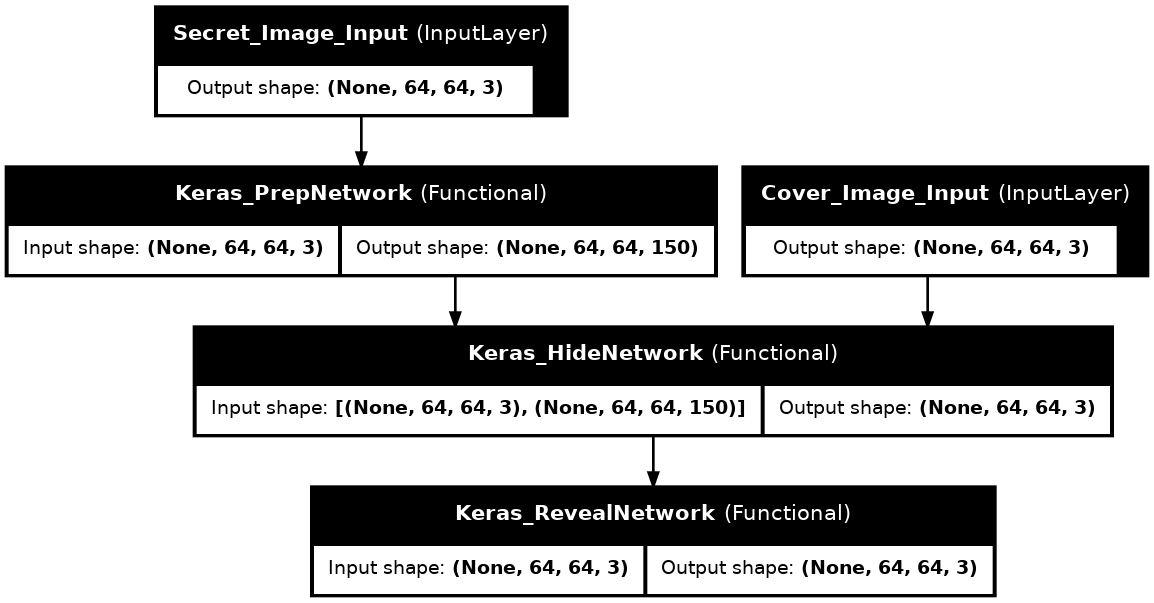

In [ ]:
import shutil
import os


# Check if the folder exists, then delete it
if CLEAR_BEFORE_TRAIN and os.path.exists(checkpoint_dir) and os.path.exists(models_dir):
    try:
        shutil.rmtree(checkpoint_dir)
        shutil.rmtree(models_dir)
        print(
            f"🗑️  Existing checkpoints in '{checkpoint_dir}' and models in '{models_dir}' have been cleared.")
    except Exception as e:
        print(f"⚠️  Error clearing checkpoints: {e}")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# Create the integrated model
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=EPOCHS * STEPS,  # Total number of training steps
    # Minimum LR as a fraction of initial (e.g., 1e-5)
    alpha=0.01
)

# 2. Pass the schedule into the Optimizer
optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    global_clipnorm=1.0
)
model = StegoSystem(prep_network, hide_network, reveal_network)
model.build([(None, 64, 64, 3), (None, 64, 64, 3)])
model.compile(optimizer=optimizer)
model.summary()

# add special plot to model how this will be used


def plot_steganography_graph():
    # 1. Define the overall inputs
    secret_in = tf.keras.Input(shape=(64, 64, 3), name="Secret_Image_Input")
    cover_in = tf.keras.Input(shape=(64, 64, 3), name="Cover_Image_Input")

    # 2. Connect the existing sub-networks
    # This mirrors exactly what happens in your train_step
    prep_out = prep_network(secret_in)
    stego_out = hide_network([cover_in, prep_out])
    reveal_out = reveal_network(stego_out)

    # 3. Create a temporary "Visualization Model"
    viz_model = tf.keras.Model(
        inputs=[cover_in, secret_in],
        outputs=[stego_out, reveal_out],
        name="Steganography_Architecture"
    )

    # 4. Plot with expansion
    return tf.keras.utils.plot_model(
        viz_model,
        to_file='steganography_full_flow.png',
        show_shapes=True,
        show_dtype=False,
        show_layer_names=True,
        rankdir='TB',
        expand_nested=False,
        dpi=96,
        layer_range=None,
        show_layer_activations=False
    )


# Execute the plot
plot_steganography_graph()

In [16]:
# Callback to save every 10 epochs
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='checkpoints/stego_best_val.weights.h5',
    monitor='val_loss',  # Monitors the validation loss from test_step
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)


class SaveEveryTen(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_dir, max_to_keep=3):
        super().__init__()
        self.checkpoint_dir = checkpoint_dir
        self.max_to_keep = max_to_keep
        # Track saved epochs to know what to delete
        self.saved_epochs = []

    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1

        if current_epoch % 10 == 0:
            print(f"\n✅ Milestone: Epoch {current_epoch} completed.")

            # 1. Manage rotation: if we already have 3, delete the oldest
            if len(self.saved_epochs) >= self.max_to_keep:
                oldest_epoch = self.saved_epochs.pop(0)
                self._delete_checkpoint(oldest_epoch)

            # 2. Save the new models
            self._save_checkpoint(current_epoch)
            self.saved_epochs.append(current_epoch)

    def _save_checkpoint(self, epoch):
        nets = ['prep', 'hide', 'reveal']
        for net_name in nets:
            net = getattr(self.model, f"{net_name}_net")
            path = os.path.join(self.checkpoint_dir,
                                f'{net_name}_model_checkpoint_{epoch}.keras')
            net.save(path)

    def _delete_checkpoint(self, epoch):
        nets = ['prep', 'hide', 'reveal']
        for net_name in nets:
            path = os.path.join(self.checkpoint_dir,
                                f'{net_name}_model_checkpoint_{epoch}.keras')
            if os.path.exists(path):
                os.remove(path)


save_callback = SaveEveryTen(checkpoint_dir=checkpoint_dir, max_to_keep=3)

callbacks = [checkpoint_callback, save_callback]
# Train using Keras Fit
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    steps_per_epoch=STEPS,
    validation_data=test_dataset,
    callbacks=callbacks,
    verbose=1
)


model.prep_net.save(prep_model_path)
model.hide_net.save(hide_model_path)
model.reveal_net.save(reveal_model_path)
print("Training completed.Final model states saved.")

results = model.evaluate(test_dataset)
print(
    f"Validation Results - Total Loss: {results[0]:.4f}, Cover Loss: {results[1]:.4f}, Secret Loss: {results[2]:.4f}")

Epoch 1/10


W0000 00:00:1774663109.402650   22917 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 200B (rounded to 256)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1774663109.402743   22917 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1774663109.402749   22917 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 295, Chunks in use: 295. 73.8KiB allocated for chunks. 73.8KiB in use in bin. 46.2KiB client-requested in use in bin.
I0000 00:00:1774663109.402755   22917 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 0, Chunks in use: 0. 0B allocated for chunks. 0B in use in bin. 0B client-requested in use in bin.
I0000 00:00:1774663109.402757   22917 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 1, Chunks in use: 1. 1.2KiB allocated for chunks. 1.2KiB in use i

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/usr/lib/python3.11/runpy.py", line 198, in _run_module_as_main

  File "/usr/lib/python3.11/runpy.py", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/ipykernel_launcher.py", line 18, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 758, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 621, in shell_main

  File "/usr/local/l

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

hist_dict = history.history if hasattr(history, 'history') else history

filename = os.path.join(data_dir, 'training_history.csv')
df = pd.DataFrame(hist_dict)
df.index.name = 'epoch'
df.to_csv(filename)
print(f"Training history saved to {filename}")

epochs = list(range(1, len(next(iter(hist_dict.values()))) + 1))

# Extract non-loss metrics (e.g., PSNR, SSIM, Acc) dynamically
metric_keys = [k for k in hist_dict.keys(
) if 'loss' not in k and 'val_' not in k and k != 'lr']

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Loss Convergence (Total, Cover, Secret)",
                    "Quality Metrics", "Learning Rate"),
    horizontal_spacing=0.08
)

# --- Panel 1: Overlapping Losses ---
# Training Losses (Blue)
fig.add_trace(go.Scatter(x=epochs, y=hist_dict['total_loss'], name="Train Total Loss",
                         line=dict(color='#636EFA', width=2), legendgroup="train"), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=hist_dict['cover_loss'], name="Train Cover Loss",
                         line=dict(color='#636EFA', width=1, dash='dash'), legendgroup="train"), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=hist_dict['secret_loss'], name="Train Secret Loss",
                         line=dict(color='#636EFA', width=1, dash='dot'), legendgroup="train"), row=1, col=1)

# Validation Losses (Orange)
if 'val_loss' in hist_dict:
    fig.add_trace(go.Scatter(x=epochs, y=hist_dict['val_loss'], name="Val Total Loss",
                             line=dict(color='#EF553B', width=2), legendgroup="val"), row=1, col=1)
    fig.add_trace(go.Scatter(x=epochs, y=hist_dict['val_cover_loss'], name="Val Cover Loss",
                             line=dict(color='#EF553B', width=1, dash='dash'), legendgroup="val"), row=1, col=1)
    fig.add_trace(go.Scatter(x=epochs, y=hist_dict['val_secret_loss'], name="Val Secret Loss",
                             line=dict(color='#EF553B', width=1, dash='dot'), legendgroup="val"), row=1, col=1)

# --- Panel 2: Other Metrics ---
colors_met = ['#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']
for i, k in enumerate(metric_keys):
    color = colors_met[i % len(colors_met)]
    fig.add_trace(go.Scatter(x=epochs, y=hist_dict[k], name=f"Train {k}",
                             line=dict(color=color, width=2)), row=1, col=2)
    if f"val_{k}" in hist_dict:
        fig.add_trace(go.Scatter(x=epochs, y=hist_dict[f"val_{k}"], name=f"Val {k}",
                                 line=dict(color=color, width=1, dash='dash')), row=1, col=2)

# --- Panel 3: Learning Rate ---
if 'lr' in hist_dict:
    fig.add_trace(go.Scatter(x=epochs, y=hist_dict['lr'], name="Learning Rate",
                             line=dict(color='#AB63FA', width=3)), row=1, col=3)

# Formatting
fig.update_yaxes(type="log", row=1, col=3)  # Log scale for LR

fig.update_layout(
    height=500, width=1500,
    title_text="Neural Network Training Progress",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom",
                y=1.02, xanchor="right", x=1)
)

fig.update_xaxes(title_text="Epoch")
fig.update_yaxes(title_text="Value", row=1, col=1)
fig.update_yaxes(title_text="Value", row=1, col=2)

# Save and Show
full_save_path = os.path.join(data_dir, "training_history.svg")
fig.write_image(full_save_path)
fig.show()

### Final Testing / Example Output

Huffman is used for all secret text, then: LSB embedding is done with [LSB_Steganography Lib](https://github.com/RobinDavid/LSB-Steganography), did ask gemini to generate basic dwt/dst to also compare with DCt/DWT embedding on images to hopefully compare robustness to the standard NN noise present in this network


In [ ]:
# Prep lsb / huffman code
from LSB_Steganography.LSBSteg import LSBSteg
from dahuffman import HuffmanCodec
import struct
from reedsolo import RSCodec

rs = RSCodec(32)

# LSB


def lsb_extract_robust(image, codec):
    steg = LSBSteg(image)

    # 1. Calculate the absolute physical limit of the image
    # (Width * Height * Channels) // 8 bits per byte
    max_bytes = (image.shape[0] * image.shape[1] * image.shape[2]) // 8

    try:
        # 2. Extract the raw bitstream from the image
        raw_binary = steg.decode_binary()
        if len(raw_binary) < 12:
            return ""  # Need at least 3 length headers (4 bytes each)

        # 3. MAJORITY VOTE ON HEADER
        # We read the first 12 bytes as three separate 32-bit integers
        h1 = struct.unpack('I', raw_binary[0:4])[0]
        h2 = struct.unpack('I', raw_binary[4:8])[0]
        h3 = struct.unpack('I', raw_binary[8:12])[0]

        # Use a simple list to find the most common value (mode)
        headers = [h1, h2, h3]
        data_len = max(set(headers), key=headers.count)

        # 4. SANITY CHECK: Hard-cap the length to the image capacity
        # If the voted length is still crazy or 0, the noise is too high
        if data_len > (max_bytes - 12) or data_len <= 0:
            raise ValueError("Header Unrecoverable")

        # 5. Extract the ECC block using the safe length
        ecc_content = raw_binary[12: 12 + data_len]
        # Debug: Show the first 20 bytes of ECC content
        # 6. Repair and Decode
        repaired_huff_bytes = rs.decode(ecc_content)[0]
        return codec.decode(repaired_huff_bytes)

    except Exception as e:
        print(f"[Unrecoverable: {str(e)[:30]}]")
        return ""


def lsb_embed_robust(text, image_array, codec):
    huff_bytes = codec.encode(text)
    ecc_bytes = rs.encode(huff_bytes)

    # Triple the length header for redundancy
    length_bin = struct.pack('I', len(ecc_bytes))
    header = length_bin * 3  # 12 bytes total

    data_to_hide = header + ecc_bytes

    steg = LSBSteg(image_array)
    return steg.encode_binary(data_to_hide)

# DCT/DWT Code


def qim_embed(x, bit, delta):
    """
    Embeds a bit (0 or 1) into coefficient x using a quantization step (delta).
    Bit 0 quantizes to even multiples, Bit 1 quantizes to odd multiples.
    """
    return np.round((x - bit * (delta / 2.0)) / delta) * delta + bit * (delta / 2.0)


def qim_extract(x, delta):
    """
    Extracts a bit from coefficient x by measuring distance to the nearest grid.
    """
    dist0 = np.abs(x - np.round(x / delta) * delta)
    dist1 = np.abs(
        x - (np.round((x - delta / 2.0) / delta) * delta + delta / 2.0))
    return (dist1 < dist0).astype(np.uint8)

# --- Binary Conversions ---


def bytes_to_bits(byte_data):
    return np.unpackbits(np.frombuffer(byte_data, dtype=np.uint8))


def bits_to_bytes(bit_array):
    return np.packbits(bit_array).tobytes()


def prepare_payload(text, codec):
    """Encodes text -> Huffman -> Reed-Solomon -> Binary Array + Triple Header"""
    huff_bytes = codec.encode(text)
    ecc_bytes = rs.encode(huff_bytes)
    # Triple header for redundancy (majority vote extraction)
    header = struct.pack('I', len(ecc_bytes)) * 3
    full_payload = header + ecc_bytes
    return bytes_to_bits(full_payload)


def decode_payload(bit_array, codec):
    """Extracts Triple Header -> majority vote length -> Reed-Solomon -> Huffman -> Text"""
    try:
        raw_bytes = bits_to_bytes(bit_array)
        if len(raw_bytes) < 12:
            return ""

        # Majority vote on header
        h1 = struct.unpack('I', raw_bytes[0:4])[0]
        h2 = struct.unpack('I', raw_bytes[4:8])[0]
        h3 = struct.unpack('I', raw_bytes[8:12])[0]
        headers = [h1, h2, h3]
        data_len = max(set(headers), key=headers.count)

        # Sanity check against image capacity limits
        if data_len <= 0 or data_len > (len(raw_bytes) - 12):
            raise ValueError("Header Unrecoverable")

        ecc_content = raw_bytes[12: 12 + data_len]
        repaired_huff_bytes = rs.decode(ecc_content)[0]
        return codec.decode(repaired_huff_bytes)
    except Exception as e:
        return ""

# DWT Specific Funcs


class DWTSteganography:
    def __init__(self, delta=15.0):
        self.delta = delta  # Higher = More robust against NN, but more visible noise

    def embed(self, image_array, text, codec):
        img_float = image_array.astype(np.float32)
        bit_array = prepare_payload(text, codec)

        # Apply 2D DWT to each channel (RGB)
        coeffs = pywt.dwt2(img_float, 'haar', axes=(0, 1))
        LL, (LH, HL, HH) = coeffs

        # Flatten the HL band to serve as our data carrier
        flat_HL = HL.flatten()

        if len(bit_array) > len(flat_HL):
            raise ValueError("Payload exceeds DWT HL band capacity!")

        # Pad bit array with random bits to match the length of the band (prevents visual artifacts from localized embedding)
        padded_bits = np.random.randint(
            0, 2, size=len(flat_HL), dtype=np.uint8)
        padded_bits[:len(bit_array)] = bit_array

        # Vectorized QIM Embedding
        flat_HL = qim_embed(flat_HL, padded_bits, self.delta)

        # Reconstruct Image
        HL = flat_HL.reshape(HL.shape)
        stego_float = pywt.idwt2((LL, (LH, HL, HH)), 'haar', axes=(0, 1))
        return np.clip(stego_float, 0, 255).astype(np.uint8)

    def extract(self, image_array, codec):
        img_float = image_array.astype(np.float32)

        # DWT Transform
        _, (_, HL, _) = pywt.dwt2(img_float, 'haar', axes=(0, 1))

        # Vectorized QIM Extraction
        extracted_bits = qim_extract(HL.flatten(), self.delta)
        return decode_payload(extracted_bits, codec)

# DCT Specific Funcs


class GridDCTSteganography:
    def __init__(self, delta=25.0):
        self.delta = delta

        # Target mid-frequency coefficients in an 8x8 DCT block.
        # (Avoids the top-left DC coeff and bottom-right high-freq noise)
        self.target_coords = [
            (3, 4), (4, 3), (4, 4), (5, 2), (2, 5), (5, 3), (3, 5)
        ]

    def _block_dct(self, img_float):
        """Vectorized 8x8 Block 2D DCT"""
        H, W, C = img_float.shape
        # Reshape to 8x8 blocks: (H/8, W/8, C, 8, 8)
        blocks = img_float.reshape(
            H//8, 8, W//8, 8, C).transpose(0, 2, 4, 1, 3)
        # Apply DCT on the last two dimensions (the 8x8 blocks)
        dct_blocks = fft.dct(
            fft.dct(blocks, axis=-1, norm='ortho'), axis=-2, norm='ortho')
        return dct_blocks

    def _block_idct(self, dct_blocks):
        """Vectorized 8x8 Block 2D Inverse DCT"""
        blocks = fft.idct(fft.idct(dct_blocks, axis=-1,
                          norm='ortho'), axis=-2, norm='ortho')
        H_8, W_8, C, _, _ = blocks.shape
        # Reconstruct standard image shape: (H, W, C)
        img_reconstructed = blocks.transpose(
            0, 3, 1, 4, 2).reshape(H_8*8, W_8*8, C)
        return img_reconstructed

    def embed(self, image_array, text, codec):
        img_float = image_array.astype(np.float32)
        bit_array = prepare_payload(text, codec)

        dct_blocks = self._block_dct(img_float)

        # Flatten our targeted coefficients across all blocks into a 1D array
        carrier_coeffs = []
        for (i, j) in self.target_coords:
            carrier_coeffs.append(dct_blocks[:, :, :, i, j].flatten())
        carrier_array = np.concatenate(carrier_coeffs)

        if len(bit_array) > len(carrier_array):
            raise ValueError(
                f"Payload ({len(bit_array)} bits) exceeds DCT Grid capacity ({len(carrier_array)} bits)!")

        padded_bits = np.random.randint(
            0, 2, size=len(carrier_array), dtype=np.uint8)
        padded_bits[:len(bit_array)] = bit_array

        # Vectorized QIM Embedding
        embedded_array = qim_embed(carrier_array, padded_bits, self.delta)

        # Place modified coefficients back into the DCT blocks
        offset = 0
        block_count = np.prod(dct_blocks.shape[:3])
        for (i, j) in self.target_coords:
            dct_blocks[:, :, :, i, j] = embedded_array[offset: offset +
                                                       block_count].reshape(dct_blocks.shape[:3])
            offset += block_count

        stego_float = self._block_idct(dct_blocks)
        return np.clip(stego_float, 0, 255).astype(np.uint8)

    def extract(self, image_array, codec):
        img_float = image_array.astype(np.float32)
        dct_blocks = self._block_dct(img_float)

        carrier_coeffs = []
        for (i, j) in self.target_coords:
            carrier_coeffs.append(dct_blocks[:, :, :, i, j].flatten())
        carrier_array = np.concatenate(carrier_coeffs)

        extracted_bits = qim_extract(carrier_array, self.delta)
        return decode_payload(extracted_bits, codec)


def calculate_ber(original, revealed):

    # Ensure we are working with 8-bit integer representations
    # We use np.clip to ensure values stay within 0-255 before casting
    orig_uint8 = np.clip(original * 255, 0, 255).astype(np.uint8)
    rev_uint8 = np.clip(revealed * 255, 0, 255).astype(np.uint8)

    # Unpack the 8-bit integers into a bit array
    # axis=-1 expands the bits for each color channel
    orig_bits = np.unpackbits(orig_uint8)
    rev_bits = np.unpackbits(rev_uint8)

    # Calculate the ratio of flipped bits to total bits
    mismatched_bits = np.sum(orig_bits != rev_bits)
    total_bits = orig_bits.size

    return mismatched_bits / total_bits

# Calculate Text Accuracy (Fixing the shadowed 'i' variable)


def acc_txt(secret, revealed):
    if len(revealed) == 0 or len(secret) == 0:
        text_acc = 0.0
    else:
        # Compare char[i] == char[i] safely using zip
        match_count = sum(1 for s_char, r_char in zip(
            secret, revealed) if s_char == r_char)

        # Divide by the original length to get the true accuracy
        text_acc = match_count / len(secret)
    return text_acc


def load_weights_from_checkpoint(models_dir, prep_net, hide_net, reveal_net):

    # Verify all files exist before attempting to load
    if not all(os.path.exists(p) for p in [prep_model_path, hide_model_path, reveal_model_path]):
        raise FileNotFoundError(
            f"⛔ CRITICAL: One or more .keras files not found in {models_dir}. "
            "Ensure you have run the individual .save() commands first."
        )

    prep_net = tf.keras.models.load_model(prep_model_path)
    hide_net = tf.keras.models.load_model(hide_model_path)
    reveal_net = tf.keras.models.load_model(reveal_model_path)
    print(f"💎 Individual weights successfully loaded from {models_dir}")
    return prep_net, hide_net, reveal_net


def to_display(img_tensor):
    # 1. Convert to numpy and remove batch dim
    arr = img_tensor.numpy().squeeze()

    # 2. Scale to 0-255
    scaled = arr * 255

    # 3. ROUND to the nearest integer, then clip, then cast
    return np.clip(np.round(scaled), 0, 255).astype(np.uint8)


def plot_final_summary(metrics_list, save_path):
    df = pd.DataFrame(metrics_list)
    methods = ['original', 'lsb', 'dct', 'dwt']
    colors = {'original': '#333333', 'lsb': '#636EFA',
              'dct': '#EF553B', 'dwt': '#00CC96'}

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Loss Analysis (Total, Cover, Secret)",
                        "PSNR: Cover vs Secret",
                        "SSIM: Cover vs Secret",
                        "Reliability (Acc & BER)"),
        vertical_spacing=0.12, horizontal_spacing=0.1
    )

    for m in methods:
        sub = df[df['method'] == m]
        idx = sub['image_index']

        # --- Plot 1: Overlapping Losses ---
        fig.add_trace(go.Scatter(x=idx, y=sub['total_loss'], name=f'{m.upper()} Total',
                                 line=dict(color=colors[m], width=2), legendgroup=m), row=1, col=1)
        fig.add_trace(go.Scatter(x=idx, y=sub['cover_loss'], name=f'{m.upper()} Cover Loss',
                                 line=dict(
                                     color=colors[m], width=1, dash='dash'),
                                 legendgroup=m, showlegend=False), row=1, col=1)
        fig.add_trace(go.Scatter(x=idx, y=sub['secret_loss'], name=f'{m.upper()} Secret Loss',
                                 line=dict(
                                     color=colors[m], width=1, dash='dot'),
                                 legendgroup=m, showlegend=False), row=1, col=1)

        # --- Plot 2: PSNR Overlap ---
        fig.add_trace(go.Scatter(x=idx, y=sub['psnr_c'], name=f'{m.upper()} PSNR-C',
                                 line=dict(color=colors[m]), legendgroup=m, showlegend=False), row=1, col=2)
        fig.add_trace(go.Scatter(x=idx, y=sub['psnr_s'], name=f'{m.upper()} PSNR-S',
                                 line=dict(color=colors[m], dash='dash'), legendgroup=m, showlegend=False), row=1, col=2)

        # --- Plot 3: SSIM Overlap ---
        fig.add_trace(go.Scatter(x=idx, y=sub['ssim_c'], name=f'{m.upper()} SSIM-C',
                                 line=dict(color=colors[m]), legendgroup=m, showlegend=False), row=2, col=1)
        fig.add_trace(go.Scatter(x=idx, y=sub['ssim_s'], name=f'{m.upper()} SSIM-S',
                                 line=dict(color=colors[m], dash='dash'), legendgroup=m, showlegend=False), row=2, col=1)

        # --- Plot 4: Reliability ---
        if m != 'original':
            fig.add_trace(go.Scatter(x=idx, y=sub['text_acc'], mode='markers+lines', name=f'{m.upper()} Acc',
                                     marker=dict(color=colors[m], size=6), legendgroup=m, showlegend=False), row=2, col=2)
        fig.add_trace(go.Scatter(x=idx, y=sub['ber'], name=f'{m.upper()} BER',
                                 line=dict(color=colors[m], dash='dashdot'), legendgroup=m, showlegend=False), row=2, col=2)

    fig.update_layout(height=900, width=1200, title_text="Steganography Audit Summary (Plotly SVG)",
                      template="plotly_white", legend_tracegroupgap=10)
    fig.update_xaxes(title_text="Image Index")

    # Save as SVG
    fig.write_image(save_path)
    fig.show()

In [ ]:

# reload just to check saved model works, and so this can be run without fit if needed.
prep_network, hide_network, reveal_network = load_weights_from_checkpoint(
    models_dir, prep_network, hide_network, reveal_network
)

# --- 1. Setup Accumulators ---
all_metrics = []

# Assuming test_cover_np and test_secret_np are your full holdout arrays
num_samples = 10  # len(holdout_cover_np)
secret_text = "Hello World!\0"
codec = HuffmanCodec.from_data(secret_text)
lsb_holdout_secret_np = []
dwt_steg = DWTSteganography(delta=15.0)
dct_steg = GridDCTSteganography(delta=25.0)
mse_handler = tf.keras.losses.MeanSquaredError()
methods = ['original', 'lsb', 'dct', 'dwt']


print(f"Evaluating {num_samples} samples...")

for i in range(num_samples):
    # Prepare single sample
    sc = to_scale(holdout_cover_np[i:i+1])
    original_secret_img = holdout_secret_np[i]

    image_results = []
    for method in methods:
        # 1. Embed Secret Data
        if method == 'original':
            # No pre-embedding, just use the raw secret image
            new_secret = original_secret_img
        elif method == 'lsb':
            new_secret = lsb_embed_robust(
                secret_text, original_secret_img, codec)
        elif method == 'dct':
            new_secret = dct_steg.embed(
                original_secret_img, secret_text, codec)
        elif method == 'dwt':
            new_secret = dwt_steg.embed(
                original_secret_img, secret_text, codec)
        ss = to_scale(np.array([new_secret]))

        # Inference
        p_out = prep_network(ss, training=False)
        h_out = hide_network([sc, p_out], training=False)
        r_out = reveal_network(h_out, training=False)
        rev_img = to_display(r_out)

        try:
            if method == 'original':
                revealed_text = ''
            elif method == 'lsb':
                revealed_text = lsb_extract_robust(rev_img, codec)
            elif method == 'dct':
                revealed_text = dct_steg.extract(rev_img, codec)
            elif method == 'dwt':
                revealed_text = dwt_steg.extract(rev_img, codec)
        except Exception as e:
            revealed_text = ""
            print(f"Sample {i+1} ({method}): decoding failed. Error: {e}")

        text_acc = acc_txt(secret_text, revealed_text)
        # Calculate Losses
        t_loss, c_loss, s_loss = steganography_loss(sc, ss, h_out, r_out)

        # Calculate Quality Metrics
        p_c = tf.image.psnr(sc, h_out, max_val=1.0).numpy()[0]
        s_c = tf.image.ssim(sc, h_out, max_val=1.0).numpy()[0]
        p_s = tf.image.psnr(ss, r_out, max_val=1.0).numpy()[0]
        s_s = tf.image.ssim(ss, r_out, max_val=1.0).numpy()[0]
        ber = calculate_ber(ss, r_out)

        all_metrics.append({
            "image_index": i,
            "method": method,
            "total_loss": float(t_loss.numpy()),
            "cover_loss": float(c_loss.numpy()),
            "secret_loss": float(s_loss.numpy()),
            "psnr_c": float(p_c),
            "ssim_c": float(s_c),
            "psnr_s": float(p_s),
            "ssim_s": float(s_s),
            "ber": float(ber),
            "text_acc": float(text_acc)
        })


# save all_metrics to csv here
df_metrics = pd.DataFrame(all_metrics)
final_summary_path = os.path.join(data_dir, "evaluation_metrics.json")
df_metrics.to_csv(final_summary_path, index=False)
print(f"Metrics saved to {final_summary_path}")

# --- 2. Final Averaging ---
print("\n=== Final Average Evaluation Metrics ===")
summary = df_metrics.groupby(
    'method')[['total_loss', 'psnr_c', 'psnr_s', 'text_acc']].mean()
print(summary)

plot_final_summary(all_metrics, os.path.join(
    data_dir, "final_summary_plot.svg"))